# Klasifikasi Gambar dengan DenseNet121 di Google Colab
Notebook ini digunakan untuk melatih model klasifikasi gambar (Normal vs Penyakit) menggunakan DenseNet121.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# Ubah path ini sesuai dengan lokasi folder 'Data Klasifikasi' di Google Drive Anda
# Contoh: '/content/drive/MyDrive/Data Klasifikasi'
base_dir = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Data Klasifikasi'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

print("Train dir:", train_dir)
print("Val dir:", val_dir)


Train dir: /content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Data Klasifikasi/train
Val dir: /content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/Data Klasifikasi/val


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Setup parameter
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Augmentasi data hanya untuk data training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validasi dan test hanya dilakukan rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1570 images belonging to 2 classes.
Found 610 images belonging to 2 classes.
Found 154 images belonging to 2 classes.


In [ ]:
# Load pre-trained DenseNet121
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze layer base model agar tidak ikut tertraining di awal
base_model.trainable = False

# Tambahkan layer custom untuk klasifikasi (2 kelas: Normal & Penyakit)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x) # 2 karena class kita ada 2 (Normal dan Penyakit)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])



29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Proses Training
EPOCHS = 100

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 714s 14s/step - accuracy: 0.6108 - loss: 0.7954 - val_accuracy: 0.7590 - val_loss: 0.5205
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 694ms/step - accuracy: 0.7420 - loss: 0.5545 - val_accuracy: 0.7492 - val_loss: 0.4994
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 674ms/step - accuracy: 0.7790 - loss: 0.4723 - val_accuracy: 0.8082 - val_loss: 0.4400
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 663ms/step - accuracy: 0.7994 - loss: 0.4367 - val_accuracy: 0.8131 - val_loss: 0.4321
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 680ms/step - accuracy: 0.8236 - loss: 0.3875 - val_accuracy: 0.8344 - val_loss: 0.4183
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 666ms/step - accuracy: 0.8223 - loss: 0.3927 - val_accuracy: 0.8246 - val_loss: 0.4320
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 669ms/step - accuracy: 0.8344 - loss: 0.3697 - val_accuracy: 0.8246 - val_loss: 0.4265
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 35s 696ms/step - accuracy: 0.8433 - loss: 0.3429 - v

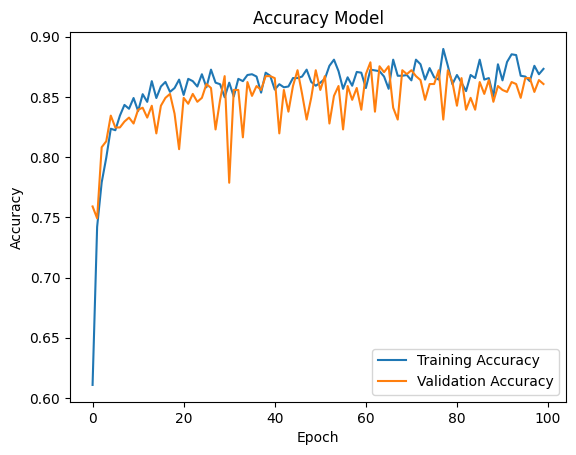

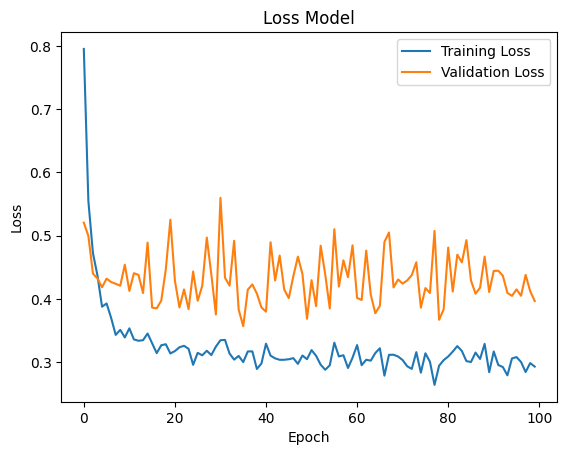

In [ ]:
import matplotlib.pyplot as plt

# Plot hasil training
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

In [ ]:
# Evaluasi pada data testing
loss, accuracy = model.evaluate(test_generator)


5/5 ━━━━━━━━━━━━━━━━━━━━ 61s 15s/step - accuracy: 0.9156 - loss: 0.2109


In [ ]:
# Menyimpan model
# Model disave dengan format .h5 untuk diletakkan di GUI nanti
model_path = '/content/drive/MyDrive/DATASET/KERJAAN DENGAN MAKCI/model_densenet121_klasifikasi.h5'
model.save(model_path)
